In [ ]:
### notes
#First I thought to calculate the speed between two consecutive rows, but then I realized that the data is spreaded across days\months between rows, 
#   also I don't know if first the user connecnted to VPN and then switch or vice versa.

#1. So I added domain_name (by IP), I created a list of kewords (known VPN providers \ known telcome companies for Non VPN) and I marked the row as accordeingly, for unknown domain I marked uncertain.
#2. In the Second step I added domain country and geo_country (based on the lan\log) geo location, 
# 	If there is more than 1 observation on a specific IP and differnt countries , then the IP is VPN
# 	If there is only one observation on the IP and the country is not 'be'(main country of the user) then mark as uncertain
# 	otherwise value stay the same as before (by domain classifcation).

# I created a DBSCAN cluster by the geo data (was not very usefull in the end), created a map visulaization with labels to review the results.

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime
from math import radians, cos, sin, asin, sqrt

In [2]:
# 1. Load DataFrame
df = pd.read_csv('C:\\Users\\liad1\\OneDrive\\מסמכים\\personal git\\work_assignments\\cyber_1\\intelos_task_detect_vpn.csv',
                 parse_dates=['REQUEST_TIME'], dayfirst=False)
df = df.sort_values(by='REQUEST_TIME').reset_index(drop=True)
df.head()

,REQUEST_TIME,DEVICE_ID,GEO_LAT,GEO_LON,IP
0,2023-11-13 18:41:00,1,50.603800,5.410800,81.242.16.58
1,2024-01-25 20:12:00,1,50.851426,4.378300,81.242.37.73
2,2024-02-23 14:58:00,1,50.520600,5.547700,81.243.5.66
3,2024-03-03 18:15:00,1,50.728650,4.430460,81.244.47.131
4,2024-03-16 22:01:00,1,50.056301,4.312722,103.86.99.40


Main calssification - Domain keywords 

# 1. Domain keywords #

In [3]:
# Find domain name by IP address
import dns.resolver
import dns.reversename

# 2. Define the alternative Domain Lookup Function using dnspython
def get_domain_via_ptr(ip):
    # Handle missing/NaN values natively without removing them
    if pd.isna(ip) or ip is None:
        return "missing_data"
        
    try:
        # Convert the standard IP string to a reverse DNS pointer format 
        # (e.g., '8.8.8.8' becomes '8.8.8.8.in-addr.arpa.')
        req_name = dns.reversename.from_address(str(ip))
        
        # Query the network specifically for PTR records
        answers = dns.resolver.resolve(req_name, 'PTR')
        
        # Extract the core string text of the domain and remove the final trailing dot (.)
        domain = str(answers[0]).rstrip('.')
        return domain
        
    except (dns.resolver.NXDOMAIN, dns.resolver.NoAnswer, dns.exception.Timeout, Exception):
        # Keeps rows intact if the DNS lookup yields no registered domain matching the IP
        return "unknown_domain"

# 3. Create the domain column safely using .apply()
df['domain_name'] = df['IP'].apply(get_domain_via_ptr)

In [ ]:
df['domain_name'] = df['domain_name'].str.replace(r'^[0-9.-]+', '', regex=True)
df['domain_name'] .head(5)

0        adsl-dyn.isp.belgacom.be
1        adsl-dyn.isp.belgacom.be
2     adsl-static.isp.belgacom.be
3        adsl-dyn.isp.belgacom.be
4                  unknown_domain
5        adsl-dyn.isp.belgacom.be
6        adsl-dyn.isp.belgacom.be
7                      choopa.net
8        adsl-dyn.isp.belgacom.be
9        adsl-dyn.isp.belgacom.be
10       adsl-dyn.isp.belgacom.be
11       adsl-dyn.isp.belgacom.be
12       adsl-dyn.isp.belgacom.be
13       adsl-dyn.isp.belgacom.be
14    adsl-static.isp.belgacom.be
15                 unknown_domain
16       adsl-dyn.isp.belgacom.be
17                 unknown_domain
18                     choopa.net
19                 unknown_domain
Name: domain_name, dtype: str

In [5]:
df.groupby(['domain_name']).size().sort_values(ascending=False).head(50)

domain_name
adsl-dyn.isp.belgacom.be               23
unknown_domain                         14
adsl-static.isp.belgacom.be             9
choopa.net                              2
host-185-77-76-18.redgeguardian.com     1
powered-by.digileuven.be                1
dtype: int64

# Classify By Domain Keywords ##

In [6]:
# 1. Ensure everything is lowercase for accurate matching
df['domain_name'] = df['domain_name'].str.lower()

# 2. Define your keyword rules
vpn_condition = df['domain_name'].str.contains('guardian|vpn|proxy|hosting|server|datacenter|ovh|linode|aws|choopa', na=False)
residential_condition = df['domain_name'].str.contains('belgacom|telecom|adsl|dynamic|pool|cable|proximus', na=False)

# 3. Create the condition choices
conditions = [vpn_condition, residential_condition]
choices = ['VPN', 'Non-VPN']

# 4. Apply the classification (anything matching neither becomes 'Uncertain')
df['CLASSIFICATION_BY_DOMAIN'] = np.select(conditions, choices, default='uncertain')

In [7]:
df.groupby('CLASSIFICATION_BY_DOMAIN').size()

CLASSIFICATION_BY_DOMAIN
Non-VPN      32
VPN           3
uncertain    15
dtype: int64

# BONUS - Additinal ways to improve the classification
# 2. Domain Location vs Geo Location #

In [8]:
# Extract the last part of the domain string (e.g., 'be' from 'belgacom.be')
df['domain_country'] = df['domain_name'].str.split('.').str[-1].str.lower()
df.groupby('domain_country').size()

domain_country
be                33
com                1
net                2
unknown_domain    14
dtype: int64

In [9]:
## find country name by geo location ##
import reverse_geocoder as rg

# Get coordinate pairs
coordinates = list(zip(df['GEO_LAT'], df['GEO_LON']))

# Perform bulk offline reverse geocoding
geo_results = rg.search(coordinates)

# Extract the 2-letter ISO country code (e.g., 'BE', 'US')
df['GEO_country'] = [res['cc'].lower() for res in geo_results]
df.groupby('GEO_country').size()

Loading formatted geocoded file...


GEO_country
be    42
fr     4
lb     1
nl     1
ru     1
us     1
dtype: int64

In [10]:
df[df.GEO_country!='be']

,REQUEST_TIME,DEVICE_ID,GEO_LAT,GEO_LON,IP,domain_name,CLASSIFICATION_BY_DOMAIN,domain_country,GEO_country
17,2024-11-04 10:20:00,1,50.39900,3.092600,92.63.196.91,unknown_domain,uncertain,unknown_domain,fr
18,2024-11-09 00:11:00,1,50.08024,3.332732,104.238.169.5,choopa.net,VPN,net,fr
23,2024-11-19 00:09:00,1,50.11115,3.738834,81.240.34.19,adsl-dyn.isp.belgacom.be,Non-VPN,be,fr
27,2024-11-23 08:28:00,1,55.73860,37.606800,92.63.196.91,unknown_domain,uncertain,unknown_domain,ru
28,2024-11-23 09:35:00,1,33.83330,35.833300,194.146.152.3,unknown_domain,uncertain,unknown_domain,lb
43,2025-05-09 04:03:00,1,37.77490,-122.419400,172.92.148.188,unknown_domain,uncertain,unknown_domain,us
45,2025-07-15 07:23:00,1,49.75474,4.941460,81.245.2.145,adsl-static.isp.belgacom.be,Non-VPN,be,fr
48,2025-10-10 07:23:00,1,51.27230,5.810700,81.245.10.203,adsl-dyn.isp.belgacom.be,Non-VPN,be,nl


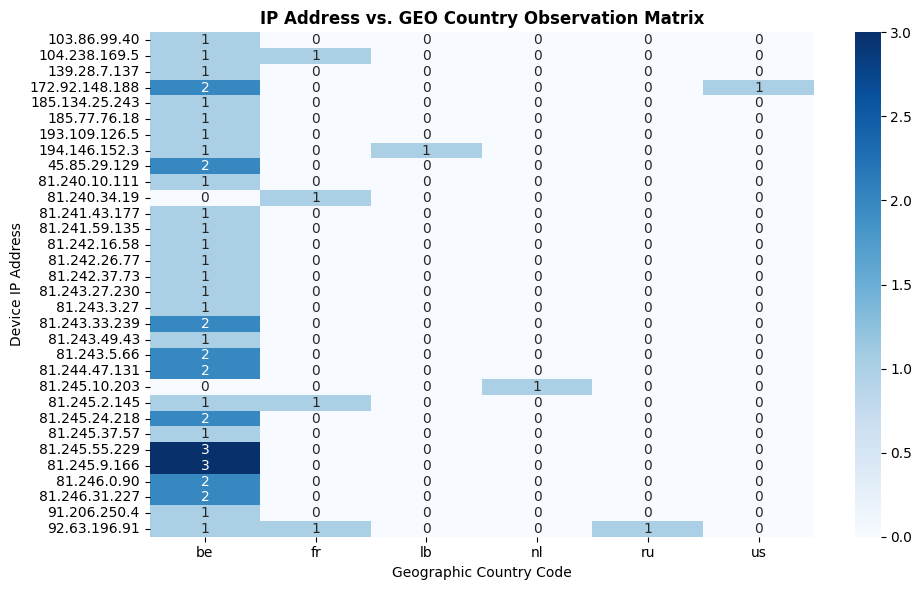

In [11]:
#Visualization - reviewing IP vs. GEO country matrix
import matplotlib.pyplot as plt
import seaborn as sns

matrix = pd.crosstab(index=df['IP'], columns=df['GEO_country'])

# Set up the figure dimensions based on the size of your matrix
plt.figure(figsize=(10, 6))

# Plot the matrix data as a heatmap
# 'annot=True' puts the raw observation counts inside the squares
sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", cbar=True)

plt.title("IP Address vs. GEO Country Observation Matrix", fontsize=12, fontweight='bold')
plt.ylabel("Device IP Address")
plt.xlabel("Geographic Country Code")
plt.tight_layout()

# Display the map directly
plt.show()

In [12]:
# rule of country mismatch :
# if there is more than 1 observation on a specific IP and differnt countries , then the IP is VPN
#  if there is only one observation on the IP and the country is not 'be'(main country of the user) then mark as uncertain
#   otherwise value stay the same as before

In [13]:
# 1. Calculate the metrics needed for the rules per IP
# We count total observations and unique country names for each IP address
ip_counts = df.groupby('IP')['GEO_country'].transform('count')  # This should be a Series aligned with the original DataFrame
ip_unique_countries = df.groupby('IP')['GEO_country'].transform('nunique')

# # 2. Define the boolean masks
# # Rule A: More than 1 observation AND different countries
rule_vpn = (ip_counts > 1) & (ip_unique_countries > 1)

# # Rule B: Exactly 1 observation AND the country is NOT 'be'
rule_uncertain = (ip_counts == 1) & (df['GEO_country'] != 'be')

# # 3. Create the condition matrix
conditions = [rule_vpn, rule_uncertain]
choices = ['VPN', 'uncertain']

# # 4. Apply the logic directly to the new column
# # If a row doesn't match Rule A or Rule B, it keeps its original value from CLASSIFICATION_BY_DOMAIN
df['CLASSIFICATION_BY_COUNTRY_MISMATCH'] = np.select(
    conditions, 
    choices, 
    default=df['CLASSIFICATION_BY_DOMAIN']
)


In [14]:
df[df.GEO_country!='be']

,REQUEST_TIME,DEVICE_ID,GEO_LAT,GEO_LON,IP,domain_name,CLASSIFICATION_BY_DOMAIN,domain_country,GEO_country,CLASSIFICATION_BY_COUNTRY_MISMATCH
17,2024-11-04 10:20:00,1,50.39900,3.092600,92.63.196.91,unknown_domain,uncertain,unknown_domain,fr,VPN
18,2024-11-09 00:11:00,1,50.08024,3.332732,104.238.169.5,choopa.net,VPN,net,fr,VPN
23,2024-11-19 00:09:00,1,50.11115,3.738834,81.240.34.19,adsl-dyn.isp.belgacom.be,Non-VPN,be,fr,uncertain
27,2024-11-23 08:28:00,1,55.73860,37.606800,92.63.196.91,unknown_domain,uncertain,unknown_domain,ru,VPN
28,2024-11-23 09:35:00,1,33.83330,35.833300,194.146.152.3,unknown_domain,uncertain,unknown_domain,lb,VPN
43,2025-05-09 04:03:00,1,37.77490,-122.419400,172.92.148.188,unknown_domain,uncertain,unknown_domain,us,VPN
45,2025-07-15 07:23:00,1,49.75474,4.941460,81.245.2.145,adsl-static.isp.belgacom.be,Non-VPN,be,fr,VPN
48,2025-10-10 07:23:00,1,51.27230,5.810700,81.245.10.203,adsl-dyn.isp.belgacom.be,Non-VPN,be,nl,uncertain


# DBSCAN Clustering for GEO location

In [16]:
#Visualization - Review VPN classification on map with Geo clustring
from sklearn.cluster import DBSCAN

# 1. Convert Latitude and Longitude to Radians for the Haversine metric
coords = df[['GEO_LAT', 'GEO_LON']].to_numpy()
kms_per_radian = 6371.0088
epsilon = 45 / kms_per_radian # 45 kilometer radius cluster

# 2. Fit the DBSCAN model
# min_samples=3 means a physical location must appear at least 3 times to be a "cluster"
db = DBSCAN(eps=epsilon, min_samples=3, metric='haversine').fit(np.radians(coords))

# 3. Add the cluster labels to the DataFrame
df['GEO_CLUSTER'] = db.labels_


In [17]:
df[['GEO_CLUSTER']].groupby('GEO_CLUSTER').size()

GEO_CLUSTER
-1     3
 0    43
 1     4
dtype: int64

In [18]:
### visualization of clusters and noise points on a map using Plotly

import plotly.express as px
import nbformat

# Ensure cluster labels are treated as strings for distinct color mapping
df['GEO_CLUSTER'] = df['GEO_CLUSTER'].astype(str)

# Create an interactive scatter mapbox
fig = px.scatter_mapbox(
    df, 
    lat="GEO_LAT", 
    lon="GEO_LON", 
    #color="GEO_CLUSTER", # Color-code based on cluster
    color='CLASSIFICATION_BY_COUNTRY_MISMATCH',
    size_max=15, 
    zoom=2,
    hover_data=["IP","domain_country",'CLASSIFICATION_BY_COUNTRY_MISMATCH','GEO_CLUSTER'],
    title="DBSCAN Geographic Clusters & Noise Mapping",
    #color_discrete_map={'-1': 'red','0': 'blue'} # Highlight noise/VPN points in Red
    color_discrete_map={'VPN': 'red','uncertain' : 'blue','Non-VPN': 'darkgreen'} # Highlight noise/VPN points in Red
)

# Use an open-source map style
fig.update_layout(mapbox_style="open-street-map")
fig.update_layout(margin={"r":0,"t":40,"l":0,"b":0})

# Display in Jupyter Notebook
fig.show()


C:\Users\liad1\AppData\Local\Temp\ipykernel_36636\4250979902.py:10: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


In [19]:
# save final file output
df.to_csv('cyber_1\\VPN_detect_results.csv', index=False)

In [ ]:
#### bonus - find optimal distance (eps) for DBSCAN using the k-distance graph ###

✅ The mathematically optimal Epsilon (ε) value is: 45.5145


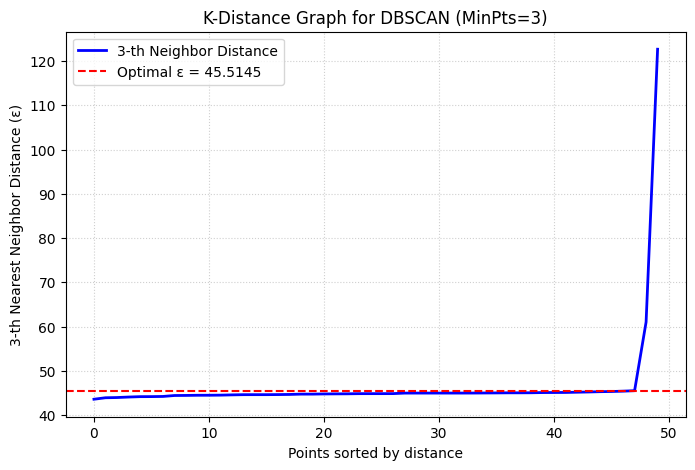

In [54]:
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from kneed import KneeLocator

min_pts = 2
k = 3

XX = df[['GEO_LAT', 'GEO_LON']].to_numpy()
XX
# -------------------------------------------------------------------------
# Step 3: Calculate the k-distances
# -------------------------------------------------------------------------
# We look for n_neighbors = k. 
# The algorithm returns distances including the point itself (distance=0),
# so the k-th nearest neighbor will be at index k-1.
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X)
distances, indices = neighbors_fit.kneighbors(XX)

# Sort distances based on the k-th nearest neighbor (last column)
sorted_k_distances = np.sort(distances[:, k-1])

# -------------------------------------------------------------------------
# Step 4: Automatically mathematically detect the "Elbow/Knee" point
# -------------------------------------------------------------------------
# Curve is 'convex' because it bends upwards, direction is 'increasing'
kneedle = KneeLocator(
    x=range(len(sorted_k_distances)), 
    y=sorted_k_distances, 
    curve="convex", 
    direction="increasing"
)

optimal_epsilon = kneedle.knee_y
print(f"✅ The mathematically optimal Epsilon (ε) value is: {optimal_epsilon:.4f}")

# -------------------------------------------------------------------------
# Step 5: Plot the k-distance graph
# -------------------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(sorted_k_distances, label=f"{k}-th Neighbor Distance", color='blue', lw=2)
plt.axhline(y=optimal_epsilon, color='red', linestyle='--', label=f'Optimal ε = {optimal_epsilon:.4f}')

plt.title(f"K-Distance Graph for DBSCAN (MinPts={k})")
plt.xlabel("Points sorted by distance")
plt.ylabel(f"{k}-th Nearest Neighbor Distance (ε)")
plt.legend(loc="upper left")
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

## old check - speed\ geo jumps ###

In [ ]:
# 2. Haversine function to calculate distance between two coordinates
def haversine(lat1, lon1, lat2, lon2):
    # Convert decimal degrees to radians
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    # Haversine formula
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a))
    r = 6371 # Radius of earth in kilometers
    return c * r

In [ ]:
# 3. Calculate Speed and Flags
df['SPEED_KMH'] = 0.0
df['CLASSIFICATION_BY_GEO_JUMPS'] = 'Non-VPN' # Default baseline

for i in range(1, len(df)):
    # Calculate time difference in hours
    time_diff = (df.loc[i, 'REQUEST_TIME'] - df.loc[i-1, 'REQUEST_TIME']).total_seconds() / 3600.0
    df.loc[i, 'TIME_DIFF_HOURS'] = time_diff

    # Calculate distance in km
    dist = haversine(df.loc[i-1, 'GEO_LAT'], df.loc[i-1, 'GEO_LON'], 
                     df.loc[i, 'GEO_LAT'], df.loc[i, 'GEO_LON'])
    df.loc[i, 'DIST_KM'] = dist

    if time_diff > 0:
        speed = dist / time_diff
        df.loc[i, 'SPEED_KMH'] = speed
        
        # If speed > 900 km/h (impossible physical travel)
        if speed > 900:
            # Mark the anomalous IP as VPN
            df.loc[i, 'CLASSIFICATION_BY_GEO_JUMPS'] = 'VPN'
            
            # Retroactively check if the previous IP was the baseline or a VPN
            if df.loc[i-1, 'IP'] != df.loc[i, 'IP']:
                 df.loc[i-1, 'CLASSIFICATION_BY_GEO_JUMPS'] = 'Uncertain'

print(df[['REQUEST_TIME', 'IP', 'GEO_LAT', 'GEO_LON', 'SPEED_KMH', 'CLASSIFICATION_BY_GEO_JUMPS']])